# Analyze 310 Complaints Historical Data

### Load Data via API

The following code can load all historical data or load a period of data through the API provided by 311 [Trash Reports](https://data.cityofnewyork.us/Social-Services/311-trash-reports/h2g7-xbpj/about_data).

In [1]:
import requests
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

In [17]:
def execute_soda_query(dataset_id, app_token, soql_query, output_file=None):
    """
    Helper function to execute a SODA3 query with pagination.

    Args:
        dataset_id (str): The ID of the dataset.
        app_token (str): The Socrata App Token.
        soql_query (str): The SQL-like query string (e.g., "SELECT *").
        output_file (str): Filename to save the data. If None, returns a pandas DataFrame.
    """
    endpoint = f"https://data.cityofnewyork.us/api/v3/views/{dataset_id}/query.json"

    headers = {
        "X-App-Token": app_token,
        "Content-Type": "application/json"
    }

    all_records = []
    page_size = 5000
    page_number = 1
    more_data = True

    print(f"Starting query on {dataset_id}...")
    print(f"Query: {soql_query}")

    try:
        while more_data:
            payload = {
                "query": soql_query,
                "page": {
                    "pageNumber": page_number,
                    "pageSize": page_size
                },
                "includeSynthetic": False
            }

            response = requests.post(endpoint, headers=headers, json=payload)

            if response.status_code == 200:
                data = response.json()

                if data:
                    all_records.extend(data)
                    print(f"Fetched {len(data)} records (Page {page_number}, Total: {len(all_records)})")

                    page_number += 1

                    if len(data) < page_size:
                        more_data = False
                else:
                    more_data = False
            else:
                print(f"Error: {response.status_code} - {response.text}")
                break

            time.sleep(0.1)
        #print('all_records len', len(all_records))
        if output_file:
            print(f"\nDownload complete. Saving {len(all_records)} records to {output_file}...")
            with open(output_file, "w") as f:
                json.dump(all_records, f, indent=4)
            print("Done!")
            return None
        else:
            return pd.DataFrame(all_records)

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

def get_all_data(dataset_id, app_token, output_file="nyc_data.json"):
    """
    Fetches all records from a Socrata dataset.
    """
    return execute_soda_query(dataset_id, app_token, "SELECT *", output_file)

def get_data_created_in_period(dataset_id, app_token, start_date, end_date, output_file="nyc_data_filtered.json"):
    """
    Fetches records created within a specific time period.

    Args:
        start_date (str): Start date (e.g., '2020-01-01').
        end_date (str): End date (e.g., '2020-01-31').
    """
    # Standardize Date Format
    try:
        s_date_iso = pd.to_datetime(start_date).strftime('%Y-%m-%dT00:00:00')
        e_date_iso = pd.to_datetime(end_date).strftime('%Y-%m-%dT23:59:59')
    except Exception as e:
        print(f"Date formatting error: {e}")
        return None

    # Construct Query
    query = f"SELECT * WHERE created_date BETWEEN '{s_date_iso}' AND '{e_date_iso}'"

    return execute_soda_query(dataset_id, app_token, query, output_file)


# Configuration
DATASET_ID = "h2g7-xbpj"
API_TOKEN = "mxlV8EDeeDtVi9W8sgFtI4E7u"

# Get all data
# get_all_data(DATASET_ID, API_TOKEN)

# Get data created in 2020
print("Fetching data created between 2020-01-01 and 2020-12-31...")
df = get_data_created_in_period(DATASET_ID, API_TOKEN, "2020-01-01", "2020-12-31", output_file=None)

if df is not None:
    print(f"Retrieved DataFrame with {len(df)} records.")
    print(df.info())
    df.to_csv('nyc_complaints_2020.csv', index=False)
    print("DataFrame saved to 'nyc_complaints_2020.csv'")

### EDA on All Historical Data

It needed a very long time to export all data via API, so we downloaded a CSV file `nyc_complaints_all.csv` from the website and started an exploratory analysis, including loading the data, displaying basic information and structure, checking for missing values, generating descriptive statistics, and analyzing and visualizing `Complaint Type` and `Created Date` to understand trends over time.

In [2]:
df = pd.read_csv('nyc_complaints_all.csv')

/tmp/ipython-input-1166942401.py:1: DtypeWarning: Columns (13,14,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('nyc_complaints_all.csv')


#### Display Basic Information and Structure


In [19]:
print(f"DataFrame has {df.shape[0]} rows and {df.shape[1]} columns.")
df.info()

DataFrame has 1764551 rows and 38 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1764551 entries, 0 to 1764550
Data columns (total 38 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   Unique Key                      int64  
 1   Created Date                    object 
 2   Closed Date                     object 
 3   Agency                          object 
 4   Agency Name                     object 
 5   Complaint Type                  object 
 6   Descriptor                      object 
 7   Location Type                   object 
 8   Incident Zip                    float64
 9   Incident Address                object 
 10  Street Name                     object 
 11  Cross Street 1                  object 
 12  Cross Street 2                  object 
 13  Intersection Street 1           object 
 14  Intersection Street 2           object 
 15  Address Type                    object 
 16  City                         

In [20]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,50700230,2021 Jun 02 12:09:00 PM,NaN,DSNY,Department of Sanitation,Sweeping/Missed-Inadequate,3 Sweeping/Missed-Inadequate,Sidewalk,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50703168,2021 Jun 02 12:09:00 PM,NaN,DSNY,Department of Sanitation,Sweeping/Missed-Inadequate,3 Sweeping/Missed-Inadequate,Sidewalk,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50697552,2021 Jun 02 12:09:00 PM,NaN,DSNY,Department of Sanitation,Sweeping/Missed-Inadequate,3 Sweeping/Missed-Inadequate,Sidewalk,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,50698218,2021 Jun 02 12:09:00 PM,NaN,DSNY,Department of Sanitation,Sweeping/Missed-Inadequate,3 Sweeping/Missed-Inadequate,Sidewalk,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,50693789,2021 Jun 02 12:09:00 PM,NaN,DSNY,Department of Sanitation,Sweeping/Missed-Inadequate,3 Sweeping/Missed-Inadequate,Sidewalk,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Check for Missing Values



In [4]:
# Calculate missing values
missing_values = df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

# Filter columns with missing values and sort
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Percentage', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Columns with Missing Values and their Percentages:")
print(missing_df)


Columns with Missing Values and their Percentages:
                                Missing Count  Missing Percentage
Bridge Highway Name                   1764551          100.000000
Bridge Highway Segment                1764551          100.000000
Road Ramp                             1764551          100.000000
Bridge Highway Direction              1764551          100.000000
Taxi Pick Up Location                 1764551          100.000000
Due Date                              1764551          100.000000
Taxi Company Borough                  1764551          100.000000
Vehicle Type                          1764551          100.000000
Landmark                              1503240           85.191077
Intersection Street 1                 1458470           82.653888
Intersection Street 2                 1458401           82.649977
Facility Type                         1420350           80.493565
Cross Street 2                          46492            2.634778
Cross Street 1           

In [5]:
# Remove Columns with more than 80% missing values
columns_to_remove = missing_df[missing_df['Missing Percentage'] > 80].index
df = df.drop(columns=columns_to_remove)


In [6]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Address Type', 'City', 'Status', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'Latitude', 'Longitude', 'Location'],
      dtype='object')

### Descriptive Statistics


In [24]:
print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())


Descriptive Statistics for Numerical Columns:
         Unique Key  Incident Zip      Latitude     Longitude
count  1.764551e+06  1.755792e+06  1.753101e+06  1.753101e+06
mean   4.564251e+07  1.098441e+04  4.069503e+01 -7.392961e+01
std    9.291507e+06  5.004906e+02  7.692029e-02  1.071183e-01
min    1.563610e+07  0.000000e+00  4.049881e+01 -7.425490e+01
25%    4.041096e+07  1.046200e+04  4.063652e+01 -7.398539e+01
50%    4.650452e+07  1.121800e+04  4.068862e+01 -7.393672e+01
75%    5.149426e+07  1.136200e+04  4.074494e+01 -7.385215e+01
max    6.691735e+07  1.234500e+04  4.091287e+01 -7.370073e+01


In [25]:
# print value counts for potential categorical columns
print("\nValue Counts for 'agency' column:")
print(df['Agency'].value_counts())

print("\nValue Counts for 'complaint_type' column:")
print(df['Complaint Type'].value_counts())

print("\nValue Counts for 'descriptor' column:")
print(df['Descriptor'].value_counts())

print("\nValue Counts for 'Location Type' column:")
print(df['Location Type'].value_counts())



Value Counts for 'agency' column:
Agency
DSNY    1764551
Name: count, dtype: int64

Value Counts for 'complaint_type' column:
Complaint Type
Request Large Bulky Item Collection    1073753
Missed Collection (All Materials)       344423
Missed Collection                       216266
Street Sweeping Complaint                33541
Litter Basket / Request                  31650
Overflowing Litter Baskets               16629
Litter Basket Request                    15116
Sweeping/Missed                           9531
Litter Basket Complaint                   6098
Sweeping/Missed-Inadequate                5913
Adopt-A-Basket                            3401
Sweeping/Inadequate                       2627
Collection Truck Noise                    2264
Request Xmas Tree Collection              1986
Seasonal Collection                        790
Recycling Basket Complaint                 366
Overflowing Recycling Baskets              196
Change Collection Schedule                   1
Name: count,

In [26]:
print("\nValue Counts for 'Address Type' column:")
print(df['Address Type'].value_counts())

print("\nValue Counts for 'City' column:")
print(df['City'].value_counts())





Value Counts for 'Address Type' column:
Address Type
ADDRESS         1707454
INTERSECTION      43095
BLOCKFACE          9908
UNRECOGNIZED         71
PLACE                 6
PLACENAME             1
Name: count, dtype: int64

Value Counts for 'City' column:
City
BROOKLYN         643033
STATEN ISLAND    195509
NEW YORK         192128
BRONX            124574
Jamaica           40958
                  ...  
brooklyn              1
queens                1
PELHAM                1
Yonkers               1
Staten Island         1
Name: count, Length: 99, dtype: int64


In [27]:
print("\nValue Counts for 'Status' column:")
print(df['Status'].value_counts())

print("\nValue Counts for 'Borough' column:")
print(df['Borough'].value_counts())



Value Counts for 'Status' column:
Status
Closed         1754504
Pending           3087
Open              2780
Assigned          2050
Unspecified       1397
In Progress        733
Name: count, dtype: int64

Value Counts for 'Borough' column:
Borough
BROOKLYN         649708
QUEENS           594226
STATEN ISLAND    196250
MANHATTAN        195851
BRONX            127127
Unspecified        1161
Name: count, dtype: int64


In [9]:
# Leave only interesting columns
df_ori = df.copy()
df = df[['Unique Key', 'Created Date', 'Closed Date', 'Complaint Type', 'Location Type', 'Borough', 'Incident Zip','Latitude', 'Longitude']]
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Complaint Type',
       'Location Type', 'Borough', 'Incident Zip', 'Latitude', 'Longitude'],
      dtype='object')

In [10]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Complaint Type',
       'Location Type', 'Borough', 'Incident Zip', 'Latitude', 'Longitude'],
      dtype='object')

In [30]:
# save df to csv
df.to_csv('nyc_complaints_all_clean.csv', index=False)

### Analyze and Visualize Complaint Types


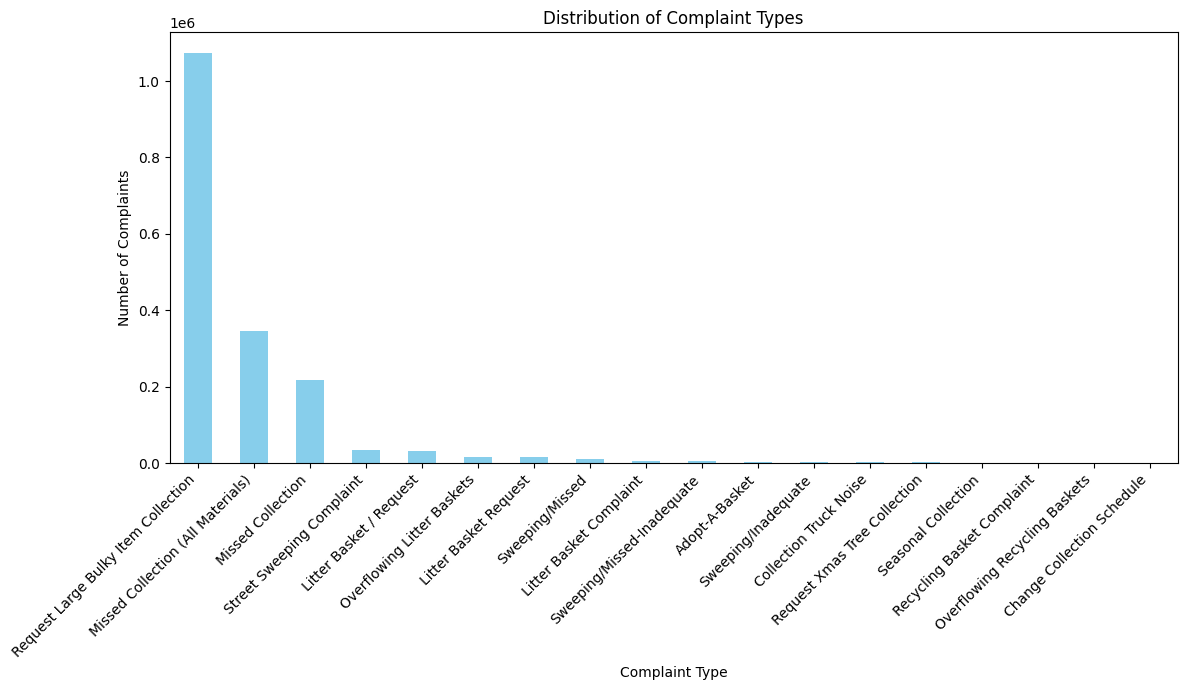

In [31]:
complaint_type_counts = df['Complaint Type'].value_counts()

plt.figure(figsize=(12, 7))
complaint_type_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Complaint Types')
plt.xlabel('Complaint Type')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualize Complaints Over Time


In [11]:
df['created_date'] = pd.to_datetime(df['Created Date'])
df['created_year'] = df['created_date'].dt.year
df['created_month'] = df['created_date'].dt.month

print("Converted 'created_date' to datetime and extracted 'created_year' and 'created_month'.")

Converted 'created_date' to datetime and extracted 'created_year' and 'created_month'.


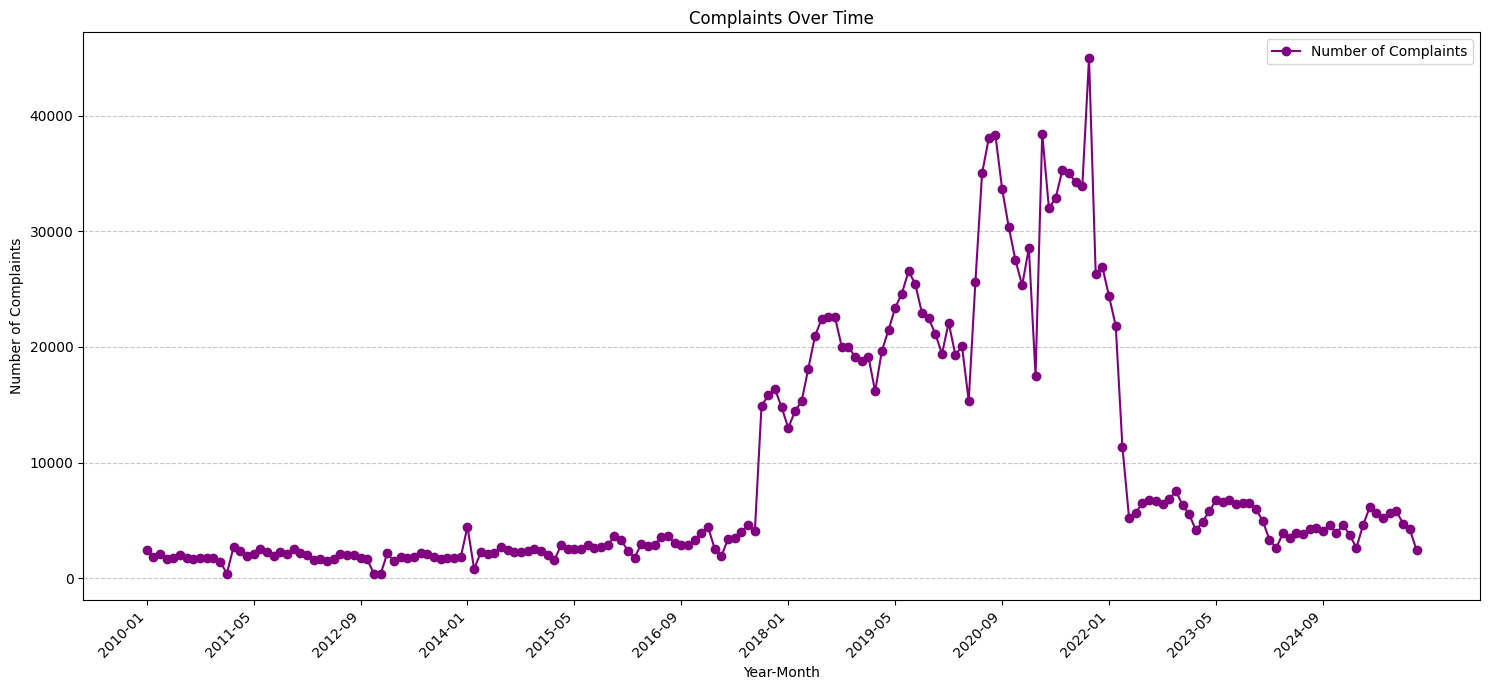

In [12]:
df['year_month'] = df['created_date'].dt.to_period('M')
complaints_over_time = df.groupby('year_month').size().reset_index(name='complaint_count')

# Sort by year_month to ensure correct plotting order
complaints_over_time = complaints_over_time.sort_values('year_month')

# Convert year_month to string for plotting labels
plot_labels = complaints_over_time['year_month'].astype(str)

plt.figure(figsize=(15, 7))
plt.plot(plot_labels, complaints_over_time['complaint_count'], marker='o', color='purple', label='Number of Complaints')
plt.title('Complaints Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Complaints')

# Reduce vertical grid lines by only showing horizontal ones
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Reduce x-ticks for better readability
num_entries = len(complaints_over_time)
if num_entries > 20: # If many entries, reduce ticks
    # Aim for roughly 10-15 ticks
    tick_interval = int(np.ceil(num_entries / 12))
    x_ticks_indices = np.arange(0, num_entries, tick_interval)
    x_ticks_labels = [plot_labels.iloc[i] for i in x_ticks_indices]
    plt.xticks(x_ticks_indices, x_ticks_labels, rotation=45, ha='right')
else:
    # If fewer entries, keep all ticks but rotate for clarity
    plt.xticks(rotation=45, ha='right')

plt.legend()
plt.tight_layout()
plt.show()

#### Visualize the Complaints of Top 3 Complaint Types


In [34]:
top_3_complaint_types = df['Complaint Type'].value_counts().nlargest(3)
print("Top 3 Most Frequent Complaint Types:")
print(top_3_complaint_types)

Top 3 Most Frequent Complaint Types:
Complaint Type
Request Large Bulky Item Collection    1073753
Missed Collection (All Materials)       344423
Missed Collection                       216266
Name: count, dtype: int64


In [35]:
top_complaint_names = top_3_complaint_types.index.tolist()
df_top_complaints = df[df['Complaint Type'].isin(top_complaint_names)]

aggregated_top_complaints = df_top_complaints.groupby(['year_month', 'Complaint Type']).size().reset_index(name='complaint_count')

print("Filtered and aggregated data for top 3 complaint types:")
print(aggregated_top_complaints.head())
print(f"Shape of aggregated_top_complaints: {aggregated_top_complaints.shape}")

Filtered and aggregated data for top 3 complaint types:
  year_month                     Complaint Type  complaint_count
0    2010-01  Missed Collection (All Materials)             2097
1    2010-02  Missed Collection (All Materials)             1505
2    2010-03  Missed Collection (All Materials)             1555
3    2010-04  Missed Collection (All Materials)             1197
4    2010-05  Missed Collection (All Materials)             1235
Shape of aggregated_top_complaints: (269, 3)


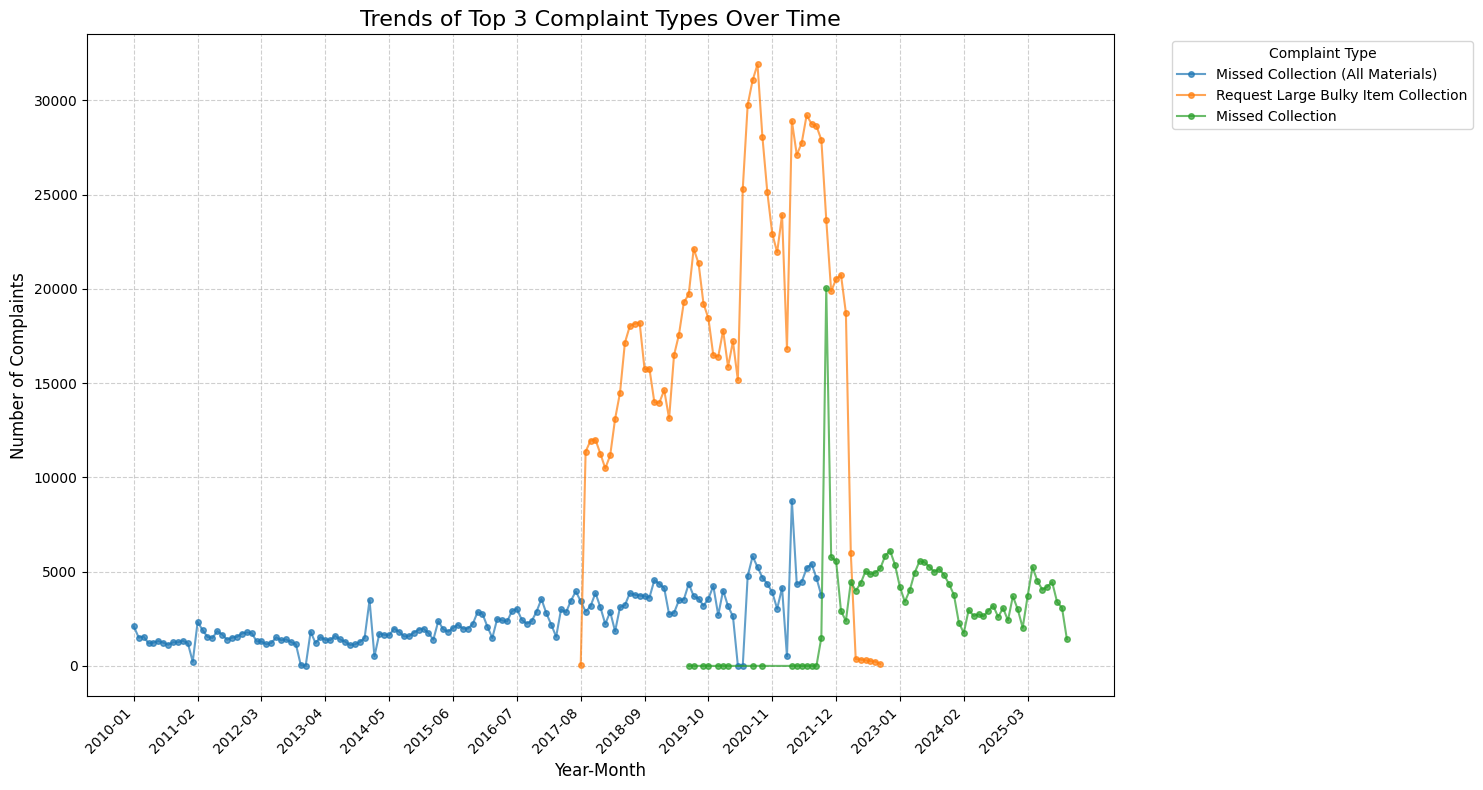

In [36]:
aggregated_top_complaints['year_month_str'] = aggregated_top_complaints['year_month'].astype(str)

plt.figure(figsize=(15, 8))

for complaint_type in aggregated_top_complaints['Complaint Type'].unique():
    df_plot = aggregated_top_complaints[aggregated_top_complaints['Complaint Type'] == complaint_type]

    plt.plot(df_plot['year_month_str'], df_plot['complaint_count'], label=complaint_type, marker='o', markersize=4, alpha=0.7)

plt.title('Trends of Top 3 Complaint Types Over Time', fontsize=16)

plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.legend(title='Complaint Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)

# Reduce x-ticks for better readability
num_entries = len(aggregated_top_complaints['year_month_str'].unique())
if num_entries > 20:
    tick_interval = int(np.ceil(num_entries / 15))
    x_ticks_labels = aggregated_top_complaints['year_month_str'].unique()
    plt.xticks(x_ticks_labels[::tick_interval])

plt.tight_layout()
plt.show()

According to this plot, `Missing Collection` is just a new name for `Missed Collection (All Materials)`. So, we can update the earlier value to the new value

In [13]:
# update 'Missed Collection (All Materials)' to 'Missing Collection' in df Complaint Type
df.loc[df['Complaint Type'] == 'Missed Collection (All Materials)', 'Complaint Type'] = 'Missing Collection'
df.loc[df['Complaint Type'] == 'Missed Collection', 'Complaint Type'] = 'Missing Collection'
# save to csv file
df.to_csv('nyc_complaints_all_clean_updated.csv', index=False)

#### Visualize the trend of other complaint types

In [38]:
sorted(df['Complaint Type'].unique())

['Adopt-A-Basket',
 'Change Collection Schedule',
 'Collection Truck Noise',
 'Litter Basket / Request',
 'Litter Basket Complaint',
 'Litter Basket Request',
 'Missing Collection',
 'Overflowing Litter Baskets',
 'Overflowing Recycling Baskets',
 'Recycling Basket Complaint',
 'Request Large Bulky Item Collection',
 'Request Xmas Tree Collection',
 'Seasonal Collection',
 'Street Sweeping Complaint',
 'Sweeping/Inadequate',
 'Sweeping/Missed',
 'Sweeping/Missed-Inadequate']

The complaint types are a little messy, so we have to merge some of them.


In [14]:
df.loc[df['Complaint Type'] == 'Litter Basket / Request', 'Complaint Type'] = 'Litter Basket Request'

df.loc[df['Complaint Type'] == 'Sweeping/Inadequate', 'Complaint Type'] = 'Sweeping/Missed-Inadequate'

df.loc[df['Complaint Type'] == 'Sweeping/Missed', 'Complaint Type'] = 'Sweeping/Missed-Inadequate'

df.to_csv('nyc_complaints_all_clean_updated.csv', index=False)

sorted(df['Complaint Type'].unique())


['Adopt-A-Basket',
 'Change Collection Schedule',
 'Collection Truck Noise',
 'Litter Basket Complaint',
 'Litter Basket Request',
 'Missing Collection',
 'Overflowing Litter Baskets',
 'Overflowing Recycling Baskets',
 'Recycling Basket Complaint',
 'Request Large Bulky Item Collection',
 'Request Xmas Tree Collection',
 'Seasonal Collection',
 'Street Sweeping Complaint',
 'Sweeping/Missed-Inadequate']

In [40]:
complaint_types_to_exclude = ['Missing Collection', 'Request Large Bulky Item Collection']
df_other_complaints = df[~df['Complaint Type'].isin(complaint_types_to_exclude)]

other_complaints_over_time = df_other_complaints.groupby(['year_month', 'Complaint Type']).size().reset_index(name='complaint_count')

print("Filtered and aggregated other complaint types successfully.")
print("First few rows of other_complaints_over_time:")
print(other_complaints_over_time.head())
print(f"Shape of other_complaints_over_time: {other_complaints_over_time.shape}")

Filtered and aggregated other complaint types successfully.
First few rows of other_complaints_over_time:
  year_month              Complaint Type  complaint_count
0    2010-01      Collection Truck Noise               13
1    2010-01       Litter Basket Request              163
2    2010-01  Overflowing Litter Baskets               80
3    2010-01  Sweeping/Missed-Inadequate               61
4    2010-02              Adopt-A-Basket                3
Shape of other_complaints_over_time: (1016, 3)


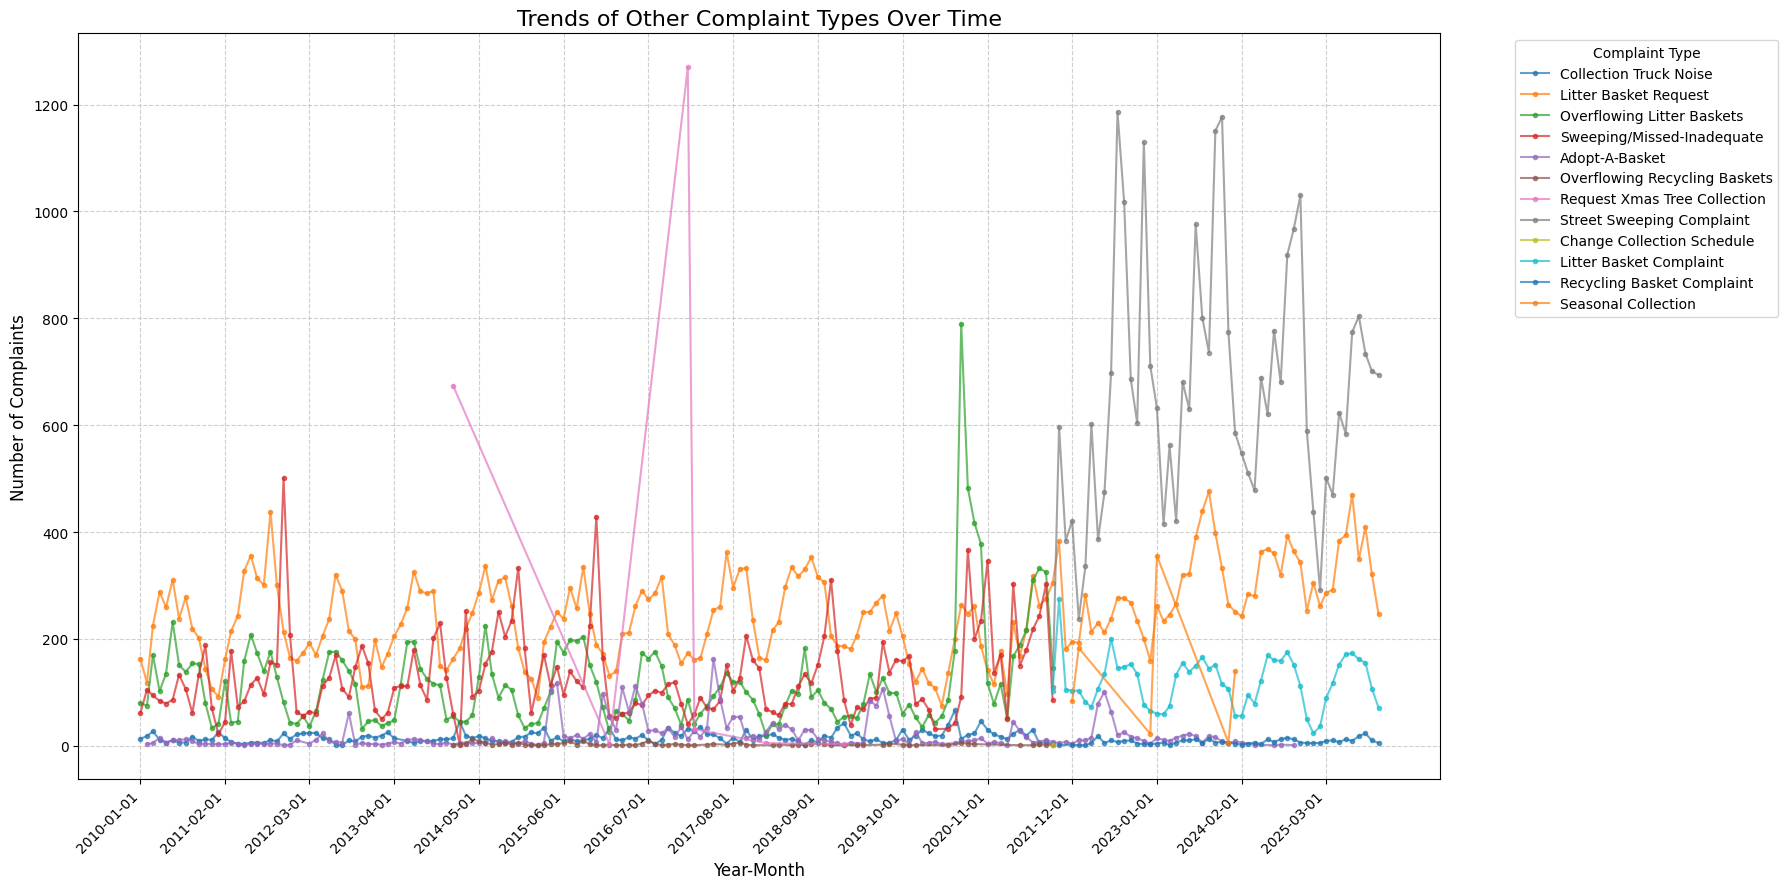

In [41]:
plt.figure(figsize=(18, 9))

other_complaints_over_time['year_month_dt'] = pd.to_datetime(
    (other_complaints_over_time['year_month'].astype(str)).str.replace('.', '-'),
    format='%Y-%m'
)
other_complaints_over_time = other_complaints_over_time.sort_values('year_month_dt')

unique_complaint_types = other_complaints_over_time['Complaint Type'].unique()

for complaint_type in unique_complaint_types:
    df_plot_filtered = other_complaints_over_time[other_complaints_over_time['Complaint Type'] == complaint_type]
    plt.plot(df_plot_filtered['year_month_dt'], df_plot_filtered['complaint_count'], label=complaint_type, marker='o', markersize=3, alpha=0.7)

plt.title('Trends of Other Complaint Types Over Time', fontsize=16)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.legend(title='Complaint Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust x-ticks for better readability
num_entries_filtered = len(other_complaints_over_time['year_month_dt'].unique())
if num_entries_filtered > 20:
    tick_interval_filtered = int(np.ceil(num_entries_filtered / 15))
    x_ticks_labels_filtered = other_complaints_over_time['year_month_dt'].unique()
    plt.xticks(x_ticks_labels_filtered[::tick_interval_filtered].astype(str), rotation=45, ha='right')
else:
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


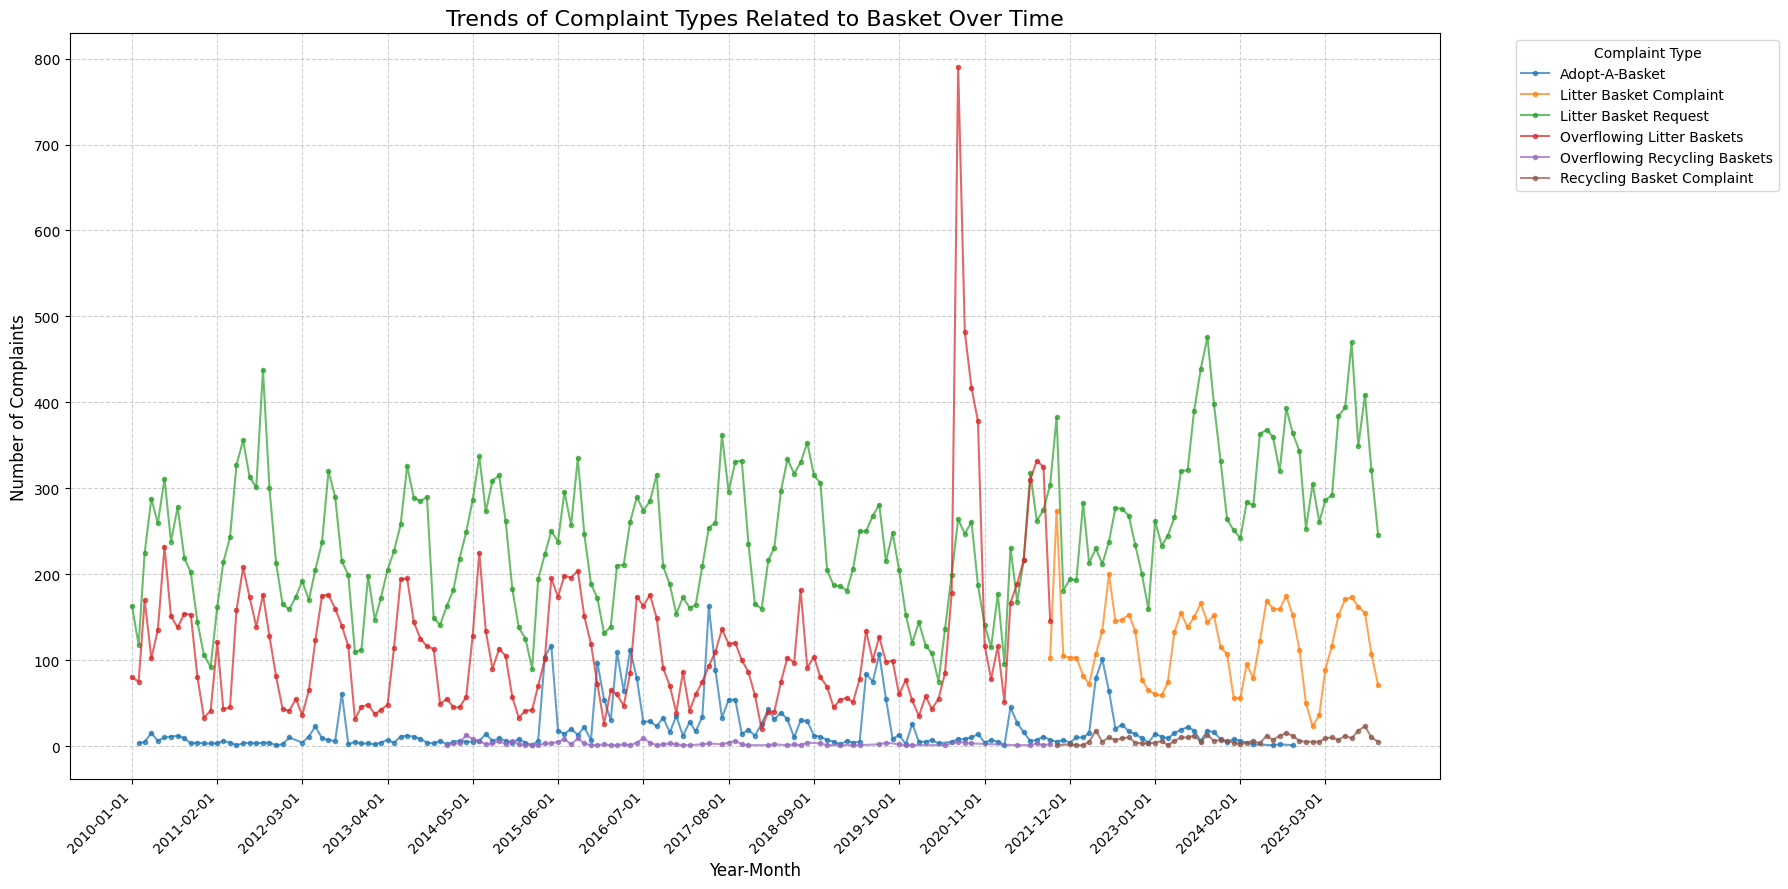

In [42]:
# plot only for the types related to Baskets
plt.figure(figsize=(18, 9))

unique_complaint_types = [
    'Adopt-A-Basket',
    'Litter Basket Complaint',
    'Litter Basket Request',
    'Overflowing Litter Baskets',
    'Overflowing Recycling Baskets',
    'Recycling Basket Complaint',
    ]

for complaint_type in unique_complaint_types:
    df_plot_filtered = other_complaints_over_time[other_complaints_over_time['Complaint Type'] == complaint_type]
    plt.plot(df_plot_filtered['year_month_dt'], df_plot_filtered['complaint_count'], label=complaint_type, marker='o', markersize=3, alpha=0.7)

plt.title('Trends of Complaint Types Related to Basket Over Time', fontsize=16)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.legend(title='Complaint Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust x-ticks for better readability
num_entries_filtered = len(other_complaints_over_time['year_month_dt'].unique())
if num_entries_filtered > 20:
    tick_interval_filtered = int(np.ceil(num_entries_filtered / 15))
    x_ticks_labels_filtered = other_complaints_over_time['year_month_dt'].unique()
    plt.xticks(x_ticks_labels_filtered[::tick_interval_filtered].astype(str), rotation=45, ha='right')
else:
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


### Plot A Map Plot by Zip Code


In [43]:
# Count complaints by Zip Code
complaints_per_zip = df['Incident Zip'].value_counts(dropna=True)
print("Complaint counts per Incident Zip code:")
print(complaints_per_zip.head())

Complaint counts per Incident Zip code:
Incident Zip
11385.0    41814
11215.0    39808
10314.0    35649
11209.0    30484
11219.0    27434
Name: count, dtype: int64


In [44]:
# Filter by NYC borough
nyc_boroughs = ['MANHATTAN', 'BROOKLYN', 'QUEENS', 'BRONX', 'STATEN ISLAND']
df_nyc = df[df['Borough'].isin(nyc_boroughs)]

print("First 5 rows of df_nyc:")
print(df_nyc.head())
print(f"\nShape of df_nyc: {df_nyc.shape}")

First 5 rows of df_nyc:
              Created Date Closed Date              Complaint Type  \
0  2021 Jun 02 12:09:00 PM         NaN  Sweeping/Missed-Inadequate   
1  2021 Jun 02 12:09:00 PM         NaN  Sweeping/Missed-Inadequate   
2  2021 Jun 02 12:09:00 PM         NaN  Sweeping/Missed-Inadequate   
3  2021 Jun 02 12:09:00 PM         NaN  Sweeping/Missed-Inadequate   
4  2021 Jun 02 12:09:00 PM         NaN  Sweeping/Missed-Inadequate   

  Location Type Borough  Incident Zip  Latitude  Longitude  \
0      Sidewalk  QUEENS           NaN       NaN        NaN   
1      Sidewalk  QUEENS           NaN       NaN        NaN   
2      Sidewalk  QUEENS           NaN       NaN        NaN   
3      Sidewalk  QUEENS           NaN       NaN        NaN   
4      Sidewalk  QUEENS           NaN       NaN        NaN   

         created_date  created_year  created_month year_month  
0 2021-06-02 12:09:00          2021              6    2021-06  
1 2021-06-02 12:09:00          2021              6    

In [45]:
# NYC Zip Code Tabulation Areas (ZCTA) GeoJSON
geoj_url = 'https://data.cityofnewyork.us/api/geospatial/pri4-ifjk?method=export&format=geojson'

try:
    # Load the GeoJSON file into a GeoDataFrame
    nyc_zip_geo = gpd.read_file(geoj_url)
    # The postalCode field in this dataset is typically named 'postalcode' and is already a string.
    # No need to convert to string or split if it's already in the correct format.
    # Let's inspect the column names first.

    # Convert 'postalcode' to string type to ensure compatibility, handling potential non-string types.
    if 'postalcode' in nyc_zip_geo.columns:
        nyc_zip_geo['postalcode'] = nyc_zip_geo['postalcode'].astype(str)
    else:
        print("Warning: 'postalcode' column not found. Please check GeoJSON structure.")

    print("GeoDataFrame for NYC zip codes loaded successfully.")
    print(nyc_zip_geo.head())
    print(f"Shape of nyc_zip_geo: {nyc_zip_geo.shape}")
except Exception as e:
    print(f"Error loading GeoJSON: {e}")
    print("Please check the URL or your network connection.")

GeoDataFrame for NYC zip codes loaded successfully.
  modzcta         label                 zcta pop_est  \
0   10001  10001, 10118  10001, 10119, 10199   23072   
1   10002         10002                10002   74993   
2   10003         10003                10003   54682   
3   10026         10026                10026   39363   
4   10004         10004                10004    3028   

                                            geometry  
0  MULTIPOLYGON (((-73.98774 40.74407, -73.98819 ...  
1  MULTIPOLYGON (((-73.9975 40.71407, -73.99709 4...  
2  MULTIPOLYGON (((-73.98864 40.72293, -73.98876 ...  
3  MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...  
4  MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...  
Shape of nyc_zip_geo: (178, 5)


In [46]:
# Ensure 'zcta' is string type in nyc_zip_geo
if 'zcta' in nyc_zip_geo.columns:
    nyc_zip_geo['zcta'] = nyc_zip_geo['zcta'].astype(str)
else:
    print("Error: 'zcta' column not found in GeoDataFrame.")

# Also ensure 'Incident Zip' in df_nyc is string type for merging
df_nyc['Incident Zip'] = df_nyc['Incident Zip'].astype(str).str.split('.').str[0]

print("Data types for relevant columns adjusted for consistency:")
print(f"nyc_zip_geo['zcta'] dtype: {nyc_zip_geo['zcta'].dtype}")
print(f"df_nyc['Incident Zip'] dtype: {df_nyc['Incident Zip'].dtype}")
print("First 5 rows of nyc_zip_geo with updated 'zcta' dtype:")
print(nyc_zip_geo.head())
print("First 5 rows of df_nyc with updated 'Incident Zip' dtype:")
print(df_nyc[['Incident Zip']].head())

Data types for relevant columns adjusted for consistency:
nyc_zip_geo['zcta'] dtype: object
df_nyc['Incident Zip'] dtype: object
First 5 rows of nyc_zip_geo with updated 'zcta' dtype:
  modzcta         label                 zcta pop_est  \
0   10001  10001, 10118  10001, 10119, 10199   23072   
1   10002         10002                10002   74993   
2   10003         10003                10003   54682   
3   10026         10026                10026   39363   
4   10004         10004                10004    3028   

                                            geometry  
0  MULTIPOLYGON (((-73.98774 40.74407, -73.98819 ...  
1  MULTIPOLYGON (((-73.9975 40.71407, -73.99709 4...  
2  MULTIPOLYGON (((-73.98864 40.72293, -73.98876 ...  
3  MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...  
4  MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...  
First 5 rows of df_nyc with updated 'Incident Zip' dtype:
  Incident Zip
0          nan
1          nan
2          nan
3          nan
4          nan


/tmp/ipython-input-2747370361.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nyc['Incident Zip'] = df_nyc['Incident Zip'].astype(str).str.split('.').str[0]


In [47]:
complaints_per_zip_df = complaints_per_zip.reset_index()
complaints_per_zip_df.columns = ['Incident Zip', 'complaint_count']

# Ensure 'Incident Zip' is string type for merging
complaints_per_zip_df['Incident Zip'] = complaints_per_zip_df['Incident Zip'].astype(str).str.split('.').str[0]

# Merge the complaint counts with the GeoDataFrame
nyc_zip_geo_merged = nyc_zip_geo.merge(complaints_per_zip_df,
                                       left_on='zcta',
                                       right_on='Incident Zip',
                                       how='left')

# Fill NaN values in 'complaint_count' with 0 for zip codes with no complaints
nyc_zip_geo_merged['complaint_count'] = nyc_zip_geo_merged['complaint_count'].fillna(0)

print("Merged GeoDataFrame with complaint counts successfully.")
print(nyc_zip_geo_merged.head())

Merged GeoDataFrame with complaint counts successfully.
  modzcta         label                 zcta pop_est  \
0   10001  10001, 10118  10001, 10119, 10199   23072   
1   10002         10002                10002   74993   
2   10003         10003                10003   54682   
3   10026         10026                10026   39363   
4   10004         10004                10004    3028   

                                            geometry Incident Zip  \
0  MULTIPOLYGON (((-73.98774 40.74407, -73.98819 ...          NaN   
1  MULTIPOLYGON (((-73.9975 40.71407, -73.99709 4...        10002   
2  MULTIPOLYGON (((-73.98864 40.72293, -73.98876 ...        10003   
3  MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...        10026   
4  MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...        10004   

   complaint_count  
0              0.0  
1           6677.0  
2          10750.0  
3           5301.0  
4            324.0  


In [48]:
import sys
!pip install mapclassify

print("mapclassify installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 18.0 MB/s eta 0:00:00
mapclassify installed.


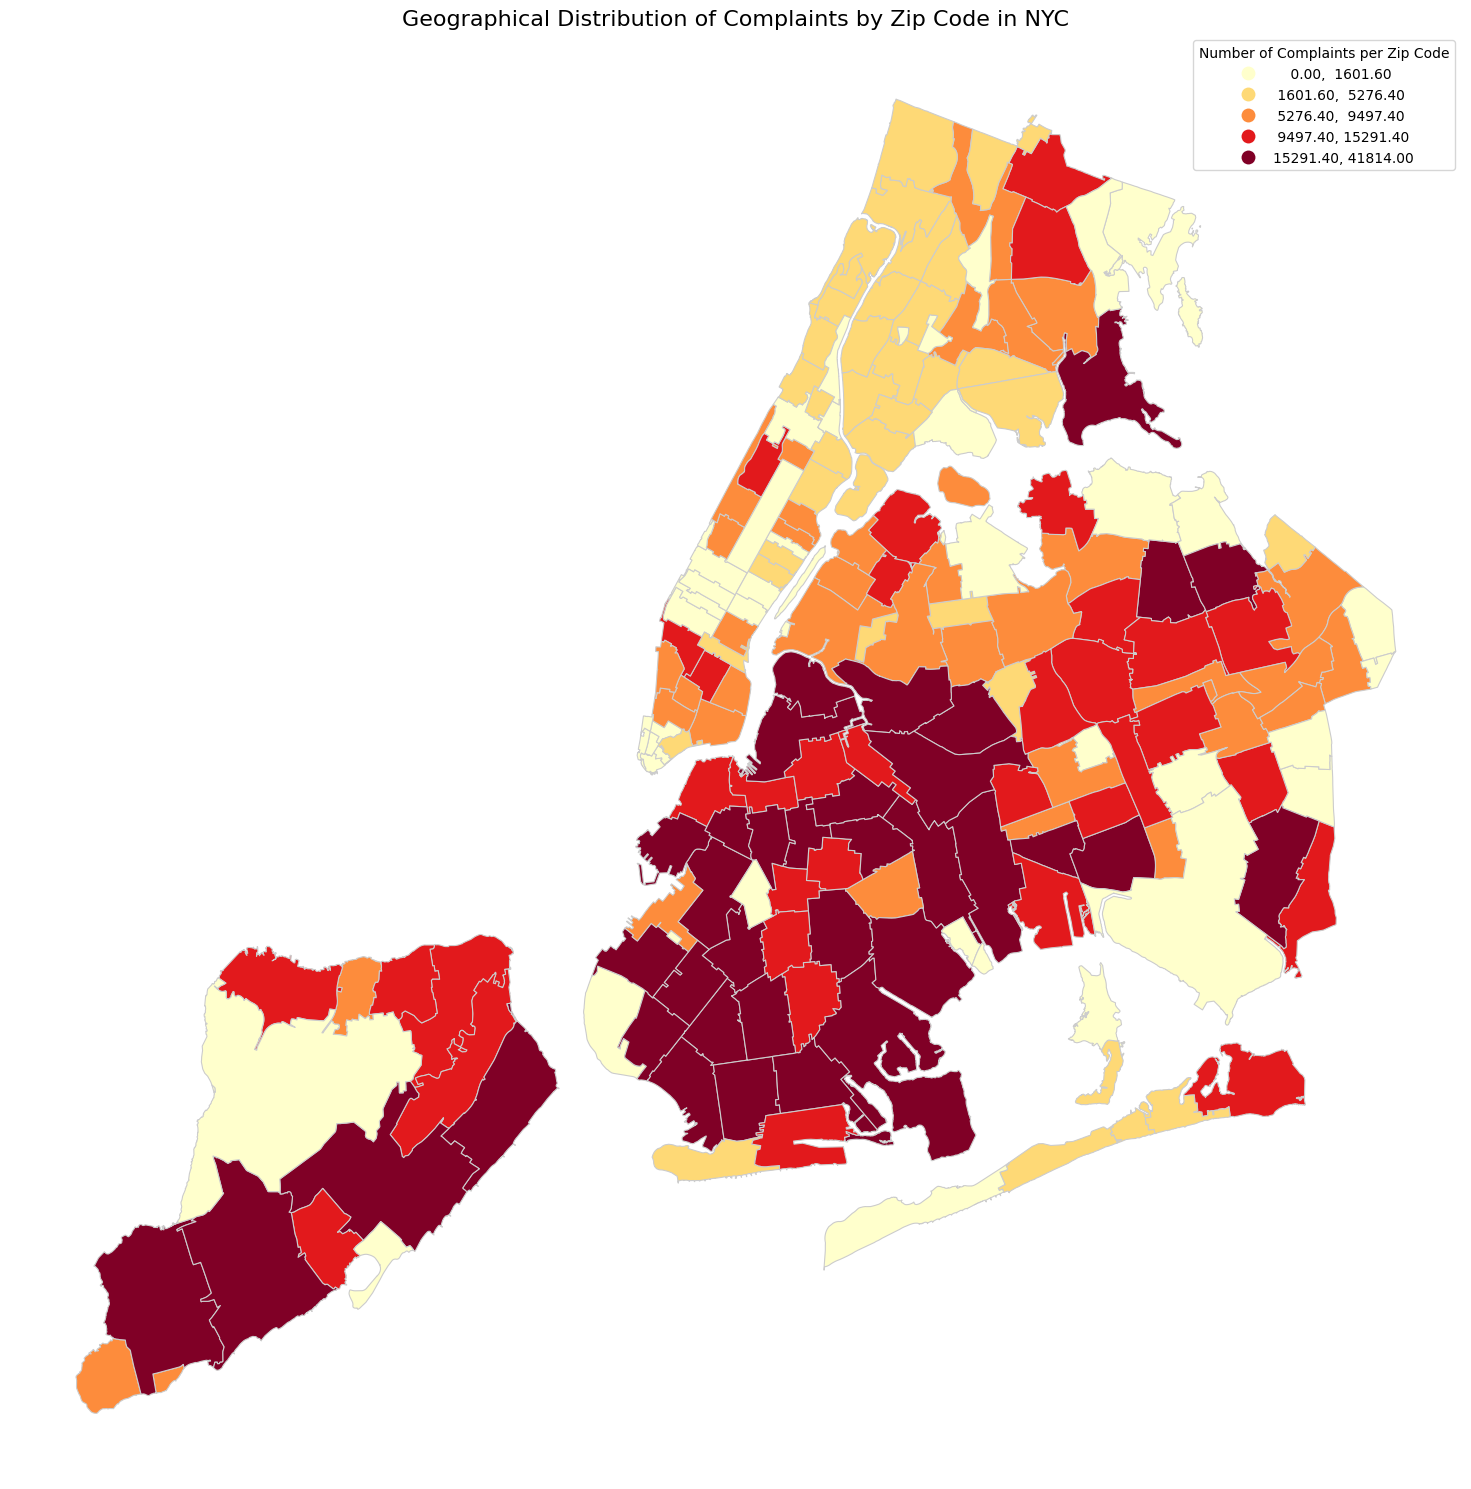

Choropleth map showing complaint distribution generated.


In [49]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
n_bins = 5

nyc_zip_geo_merged.plot(
    column='complaint_count',
    cmap='YlOrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'title': "Number of Complaints per Zip Code"},
    scheme='Quantiles', # Using quantiles for better distribution across colors
    k=n_bins # Number of quantiles
)

ax.set_title('Geographical Distribution of Complaints by Zip Code in NYC', fontsize=16)
ax.set_axis_off() # Hide the axes
plt.tight_layout()
plt.show()

print("Choropleth map showing complaint distribution generated.")

## Visualize Complaint Density using Hexagonal Binning


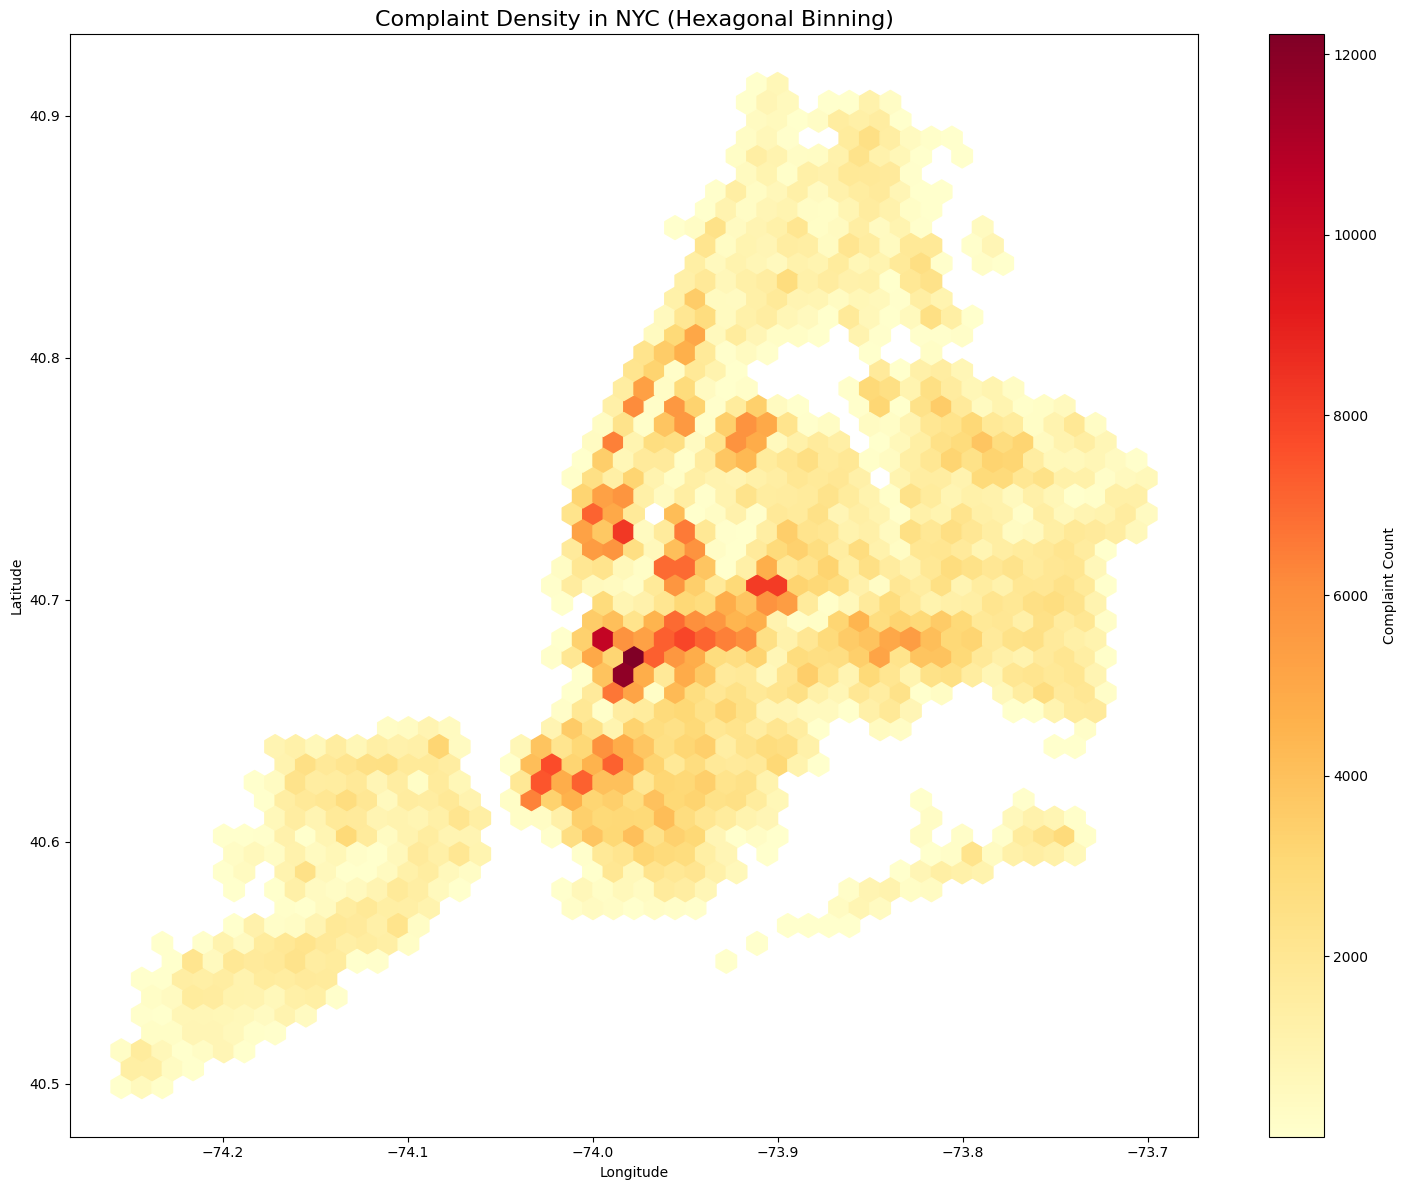

Hexagonal binning plot showing complaint density generated.


In [50]:
# Filter out rows with NaN in Latitude or Longitude for hexbin plotting
df_geo = df_nyc.dropna(subset=['Latitude', 'Longitude']).copy()

plt.figure(figsize=(15, 12))
plt.hexbin(
    df_geo['Longitude'],
    df_geo['Latitude'],
    gridsize=50, # Adjust gridsize for desired granularity
    cmap='YlOrRd',
    mincnt=1 # Only show bins with at least one complaint
)

# Add a colorbar to indicate complaint density
cbar = plt.colorbar()
cbar.set_label('Complaint Count')

plt.title('Complaint Density in NYC (Hexagonal Binning)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

print("Hexagonal binning plot showing complaint density generated.")

## Complaint by Community Districts



In [51]:
df_community_districts = pd.read_csv('/content/Community_Districts.csv')
print("DataFrame 'df_community_districts' loaded successfully.")

DataFrame 'df_community_districts' loaded successfully.


In [52]:
print("First few rows of df_community_districts:")
print(df_community_districts.head())

print("\nDataFrame info for df_community_districts:")
df_community_districts.info()

print("\nColumn names in df_community_districts:")
print(df_community_districts.columns.tolist())

First few rows of df_community_districts:
   BoroCd   Shape_Length    Shape_Area  \
0     410  105822.377329  1.720774e+08   
1     480   47338.740067  3.277756e+07   
2     104   67546.045387  4.931005e+07   
3     107   39863.703295  5.315258e+07   
4     317   43327.354912  9.381843e+07   

                                            the_geom  
0  MULTIPOLYGON (((-73.85722330984474 40.65027867...  
1  MULTIPOLYGON (((-73.86272021413627 40.76667064...  
2  MULTIPOLYGON (((-73.99393694248319 40.77317951...  
3  MULTIPOLYGON (((-73.95964685423152 40.80115642...  
4  MULTIPOLYGON (((-73.90755209573506 40.65118592...  

DataFrame info for df_community_districts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   BoroCd        71 non-null     int64  
 1   Shape_Length  71 non-null     float64
 2   Shape_Area    71 non-null     float64
 3   the_geom 

In [53]:
from shapely.geometry import Point

# 1. Filter out rows with missing Latitude or Longitude
df_complaints_geo = df_nyc.dropna(subset=['Latitude', 'Longitude']).copy()

# 2. Create point geometries
df_complaints_geo['geometry'] = df_complaints_geo.apply(
    lambda row: Point(row['Longitude'], row['Latitude']), axis=1
)

# 3. Convert to GeoDataFrame and set CRS
# EPSG:4326 corresponds to WGS84, which uses latitude and longitude coordinates.
geodata_complaints = gpd.GeoDataFrame(df_complaints_geo, geometry='geometry', crs='EPSG:4326')

print("GeoDataFrame 'geodata_complaints' created successfully.")
print("First few rows of geodata_complaints:")
print(geodata_complaints.head())
print(f"\nShape of geodata_complaints: {geodata_complaints.shape}")

GeoDataFrame 'geodata_complaints' created successfully.
First few rows of geodata_complaints:
                Created Date              Closed Date  \
180  2013 Dec 31 12:27:00 PM  2014 Jan 09 12:00:00 PM   
181  2013 Dec 31 11:13:00 AM  2014 Jan 02 12:00:00 PM   
182  2013 Dec 31 10:27:00 AM  2014 Jan 05 12:00:00 PM   
183  2013 Dec 31 10:05:00 AM  2014 Jan 02 12:00:00 PM   
184  2013 Dec 30 02:19:00 PM  2013 Dec 31 12:00:00 PM   

                 Complaint Type Location Type   Borough Incident Zip  \
180  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN        11214   
181  Sweeping/Missed-Inadequate      Sidewalk     BRONX        10472   
182  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN        11215   
183  Sweeping/Missed-Inadequate      Sidewalk     BRONX        10472   
184  Sweeping/Missed-Inadequate      Sidewalk    QUEENS        11369   

      Latitude  Longitude        created_date  created_year  created_month  \
180  40.589433 -73.990070 2013-12-31 12:27:00       

In [54]:
import geopandas as gpd
from shapely import wkt

# Convert the 'the_geom' column (WKT) to actual geometry objects
df_community_districts['geometry'] = df_community_districts['the_geom'].apply(wkt.loads)

# Create a GeoDataFrame from df_community_districts
# Assuming EPSG:4326 (WGS84) as a common CRS for geographical data if not explicitly stated.
# It's good practice to verify the actual CRS of the WKT data if possible.
nyc_cd_geo = gpd.GeoDataFrame(df_community_districts, geometry='geometry', crs='EPSG:4326')

print("GeoDataFrame 'nyc_cd_geo' created successfully from 'Community_Districts.csv'.")
print("First few rows of nyc_cd_geo:")
print(nyc_cd_geo.head())
print(f"\nShape of nyc_cd_geo: {nyc_cd_geo.shape}")

GeoDataFrame 'nyc_cd_geo' created successfully from 'Community_Districts.csv'.
First few rows of nyc_cd_geo:
   BoroCd   Shape_Length    Shape_Area  \
0     410  105822.377329  1.720774e+08   
1     480   47338.740067  3.277756e+07   
2     104   67546.045387  4.931005e+07   
3     107   39863.703295  5.315258e+07   
4     317   43327.354912  9.381843e+07   

                                            the_geom  \
0  MULTIPOLYGON (((-73.85722330984474 40.65027867...   
1  MULTIPOLYGON (((-73.86272021413627 40.76667064...   
2  MULTIPOLYGON (((-73.99393694248319 40.77317951...   
3  MULTIPOLYGON (((-73.95964685423152 40.80115642...   
4  MULTIPOLYGON (((-73.90755209573506 40.65118592...   

                                            geometry  
0  MULTIPOLYGON (((-73.85722 40.65028, -73.85902 ...  
1  MULTIPOLYGON (((-73.86272 40.76667, -73.86281 ...  
2  MULTIPOLYGON (((-73.99394 40.77318, -73.9937 4...  
3  MULTIPOLYGON (((-73.95965 40.80116, -73.95883 ...  
4  MULTIPOLYGON (((-73.907

In [55]:
# Perform Spatial Join and Aggregate Complaints
import geopandas as gpd

# Ensure both GeoDataFrames have the same CRS before spatial joining
# geodata_complaints already has EPSG:4326
# nyc_cd_geo already has EPSG:4326

# Perform spatial join using 'within' predicate
# This will add community district information to each complaint that falls within a district
complaints_with_cd = gpd.sjoin(geodata_complaints, nyc_cd_geo, how='inner', predicate='within')

print("Spatial join completed successfully.")
print("First few rows of complaints_with_cd:")
print(complaints_with_cd.head())
print(f"\nShape of complaints_with_cd: {complaints_with_cd.shape}")

Spatial join completed successfully.
First few rows of complaints_with_cd:
                Created Date              Closed Date  \
180  2013 Dec 31 12:27:00 PM  2014 Jan 09 12:00:00 PM   
181  2013 Dec 31 11:13:00 AM  2014 Jan 02 12:00:00 PM   
182  2013 Dec 31 10:27:00 AM  2014 Jan 05 12:00:00 PM   
183  2013 Dec 31 10:05:00 AM  2014 Jan 02 12:00:00 PM   
184  2013 Dec 30 02:19:00 PM  2013 Dec 31 12:00:00 PM   

                 Complaint Type Location Type   Borough Incident Zip  \
180  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN        11214   
181  Sweeping/Missed-Inadequate      Sidewalk     BRONX        10472   
182  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN        11215   
183  Sweeping/Missed-Inadequate      Sidewalk     BRONX        10472   
184  Sweeping/Missed-Inadequate      Sidewalk    QUEENS        11369   

      Latitude  Longitude        created_date  created_year  created_month  \
180  40.589433 -73.990070 2013-12-31 12:27:00          2013            

In [56]:
# Group by 'BoroCd' and count complaints per community district
complaints_per_cd = complaints_with_cd.groupby('BoroCd').size().reset_index(name='complaint_count')

# Merge the complaint counts with the nyc_cd_geo GeoDataFrame
# nyc_cd_geo contains the geometry for each community district
nyc_cd_geo_merged = nyc_cd_geo.merge(complaints_per_cd, on='BoroCd', how='left')

# Fill NaN values in 'complaint_count' with 0 for districts with no complaints
nyc_cd_geo_merged['complaint_count'] = nyc_cd_geo_merged['complaint_count'].fillna(0)

print("Aggregated complaints per community district and merged with geographical data successfully.")
print("First few rows of complaints_per_cd:")
print(complaints_per_cd.head())
print("\nFirst few rows of nyc_cd_geo_merged:")
print(nyc_cd_geo_merged.head())

Aggregated complaints per community district and merged with geographical data successfully.
First few rows of complaints_per_cd:
   BoroCd  complaint_count
0     101             6880
1     102            23261
2     103            21426
3     104            20290
4     105             8295

First few rows of nyc_cd_geo_merged:
   BoroCd   Shape_Length    Shape_Area  \
0     410  105822.377329  1.720774e+08   
1     480   47338.740067  3.277756e+07   
2     104   67546.045387  4.931005e+07   
3     107   39863.703295  5.315258e+07   
4     317   43327.354912  9.381843e+07   

                                            the_geom  \
0  MULTIPOLYGON (((-73.85722330984474 40.65027867...   
1  MULTIPOLYGON (((-73.86272021413627 40.76667064...   
2  MULTIPOLYGON (((-73.99393694248319 40.77317951...   
3  MULTIPOLYGON (((-73.95964685423152 40.80115642...   
4  MULTIPOLYGON (((-73.90755209573506 40.65118592...   

                                            geometry  complaint_count  
0  MULTI

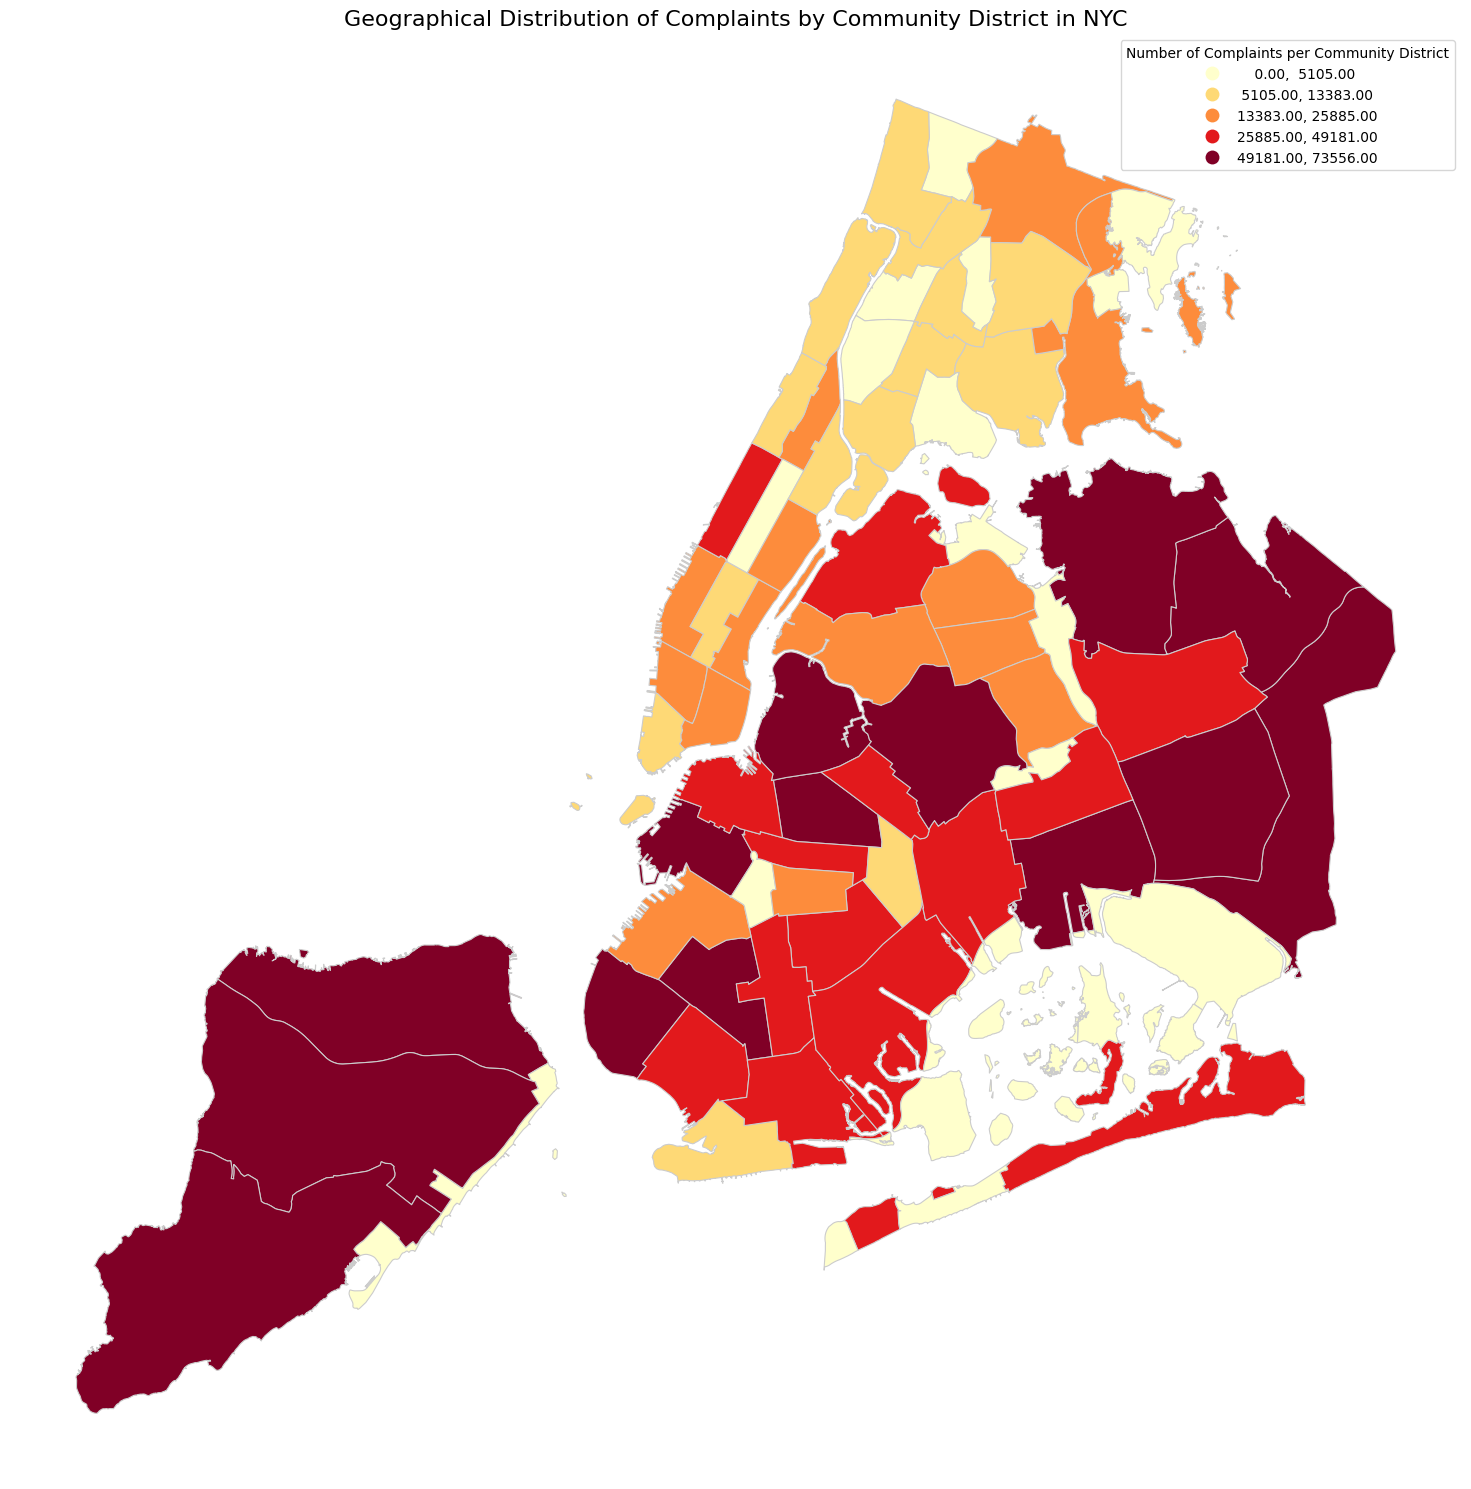

Choropleth map showing complaint distribution by community district generated.


In [57]:
# Visualize Complaint Counts by Community District

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
n_bins = 5

nyc_cd_geo_merged.plot(
    column='complaint_count',
    cmap='YlOrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'title': "Number of Complaints per Community District"},
    scheme='Quantiles', # Using quantiles for better distribution across colors
    k=n_bins # Number of quantiles
)

ax.set_title('Geographical Distribution of Complaints by Community District in NYC', fontsize=16)
ax.set_axis_off() # Hide the axes
plt.tight_layout()
plt.show()

print("Choropleth map showing complaint distribution by community district generated.")

## Complaints by Neighborhood Tabulation Area (NTA)

`nynta2020_25d.zip` contains Neighborhood Tabulation Area (NTA) data

In [58]:
import zipfile
import os

zip_file_path = 'nynta2020_25d.zip'
extract_dir = 'nynta2020_25d'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Contents of {zip_file_path} extracted to {extract_dir}/")
# List the contents of the extracted directory to verify
print("Extracted files:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))


Contents of nynta2020_25d.zip extracted to nynta2020_25d/
Extracted files:
nynta2020_25d/nynta2020_25d/nynta2020.shp
nynta2020_25d/nynta2020_25d/nynta2020.shx
nynta2020_25d/nynta2020_25d/nynta2020.prj
nynta2020_25d/nynta2020_25d/nynta2020.dbf
nynta2020_25d/nynta2020_25d/nynta2020.shp.xml


In [59]:
# Define the path to the main shapefile (.shp file) within the extracted directory
shp_file_path = 'nynta2020_25d/nynta2020_25d/nynta2020.shp'

try:
    # Load the shapefile into a GeoDataFrame
    nyc_nta_geo = gpd.read_file(shp_file_path)

    print("GeoDataFrame for NYC Neighborhood Tabulation Areas loaded successfully.")
    print("First few rows of nyc_nta_geo:")
    print(nyc_nta_geo.head())
    print(f"\nShape of nyc_nta_geo: {nyc_nta_geo.shape}")
except Exception as e:
    print(f"Error loading shapefile: {e}")
    print(f"Please ensure the file '{shp_file_path}' exists in the expected location.")

GeoDataFrame for NYC Neighborhood Tabulation Areas loaded successfully.
First few rows of nyc_nta_geo:
   BoroCode  BoroName CountyFIPS NTA2020             NTAName  NTAAbbrev  \
0         3  Brooklyn        047  BK0101          Greenpoint      Grnpt   
1         3  Brooklyn        047  BK0102        Williamsburg   Wllmsbrg   
2         3  Brooklyn        047  BK0103  South Williamsburg  SWllmsbrg   
3         3  Brooklyn        047  BK0104   East Williamsburg  EWllmsbrg   
4         3  Brooklyn        047  BK0201    Brooklyn Heights      BkHts   

  NTAType CDTA2020                                           CDTAName  \
0       0     BK01     BK01 Williamsburg-Greenpoint (CD 1 Equivalent)   
1       0     BK01     BK01 Williamsburg-Greenpoint (CD 1 Equivalent)   
2       0     BK01     BK01 Williamsburg-Greenpoint (CD 1 Equivalent)   
3       0     BK01     BK01 Williamsburg-Greenpoint (CD 1 Equivalent)   
4       0     BK02  BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...   

     Sh

In [60]:
print(f"CRS of geodata_complaints: {geodata_complaints.crs}")
print(f"CRS of nyc_nta_geo: {nyc_nta_geo.crs}")

CRS of geodata_complaints: EPSG:4326
CRS of nyc_nta_geo: EPSG:2263


In [61]:
# Perform Spatial Join with NTAs

# Reproject nyc_nta_geo to EPSG:4326 to match geodata_complaints
nyc_nta_geo = nyc_nta_geo.to_crs(geodata_complaints.crs)

# Perform spatial join using 'within' predicate
# This will add NTA information to each complaint that falls within an NTA
complaints_with_nta = gpd.sjoin(geodata_complaints, nyc_nta_geo, how='inner', predicate='within')

print("Spatial join completed successfully.")
print("First few rows of complaints_with_nta:")
print(complaints_with_nta.head())
print(f"\nShape of complaints_with_nta: {complaints_with_nta.shape}")

Spatial join completed successfully.
First few rows of complaints_with_nta:
                Created Date              Closed Date  \
180  2013 Dec 31 12:27:00 PM  2014 Jan 09 12:00:00 PM   
181  2013 Dec 31 11:13:00 AM  2014 Jan 02 12:00:00 PM   
182  2013 Dec 31 10:27:00 AM  2014 Jan 05 12:00:00 PM   
183  2013 Dec 31 10:05:00 AM  2014 Jan 02 12:00:00 PM   
184  2013 Dec 30 02:19:00 PM  2013 Dec 31 12:00:00 PM   

                 Complaint Type Location Type   Borough Incident Zip  \
180  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN        11214   
181  Sweeping/Missed-Inadequate      Sidewalk     BRONX        10472   
182  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN        11215   
183  Sweeping/Missed-Inadequate      Sidewalk     BRONX        10472   
184  Sweeping/Missed-Inadequate      Sidewalk    QUEENS        11369   

      Latitude  Longitude        created_date  created_year  ...  BoroName  \
180  40.589433 -73.990070 2013-12-31 12:27:00          2013  ...  Broo

In [62]:
# Aggregate Complaint Counts by NTA
complaints_per_nta = complaints_with_nta.groupby('NTA2020').size().reset_index(name='complaint_count')

print("Total complaints per Neighborhood Tabulation Area:")
print(complaints_per_nta.head())

Total complaints per Neighborhood Tabulation Area:
  NTA2020  complaint_count
0  BK0101            17935
1  BK0102            17358
2  BK0103             7765
3  BK0104            14891
4  BK0201             5503


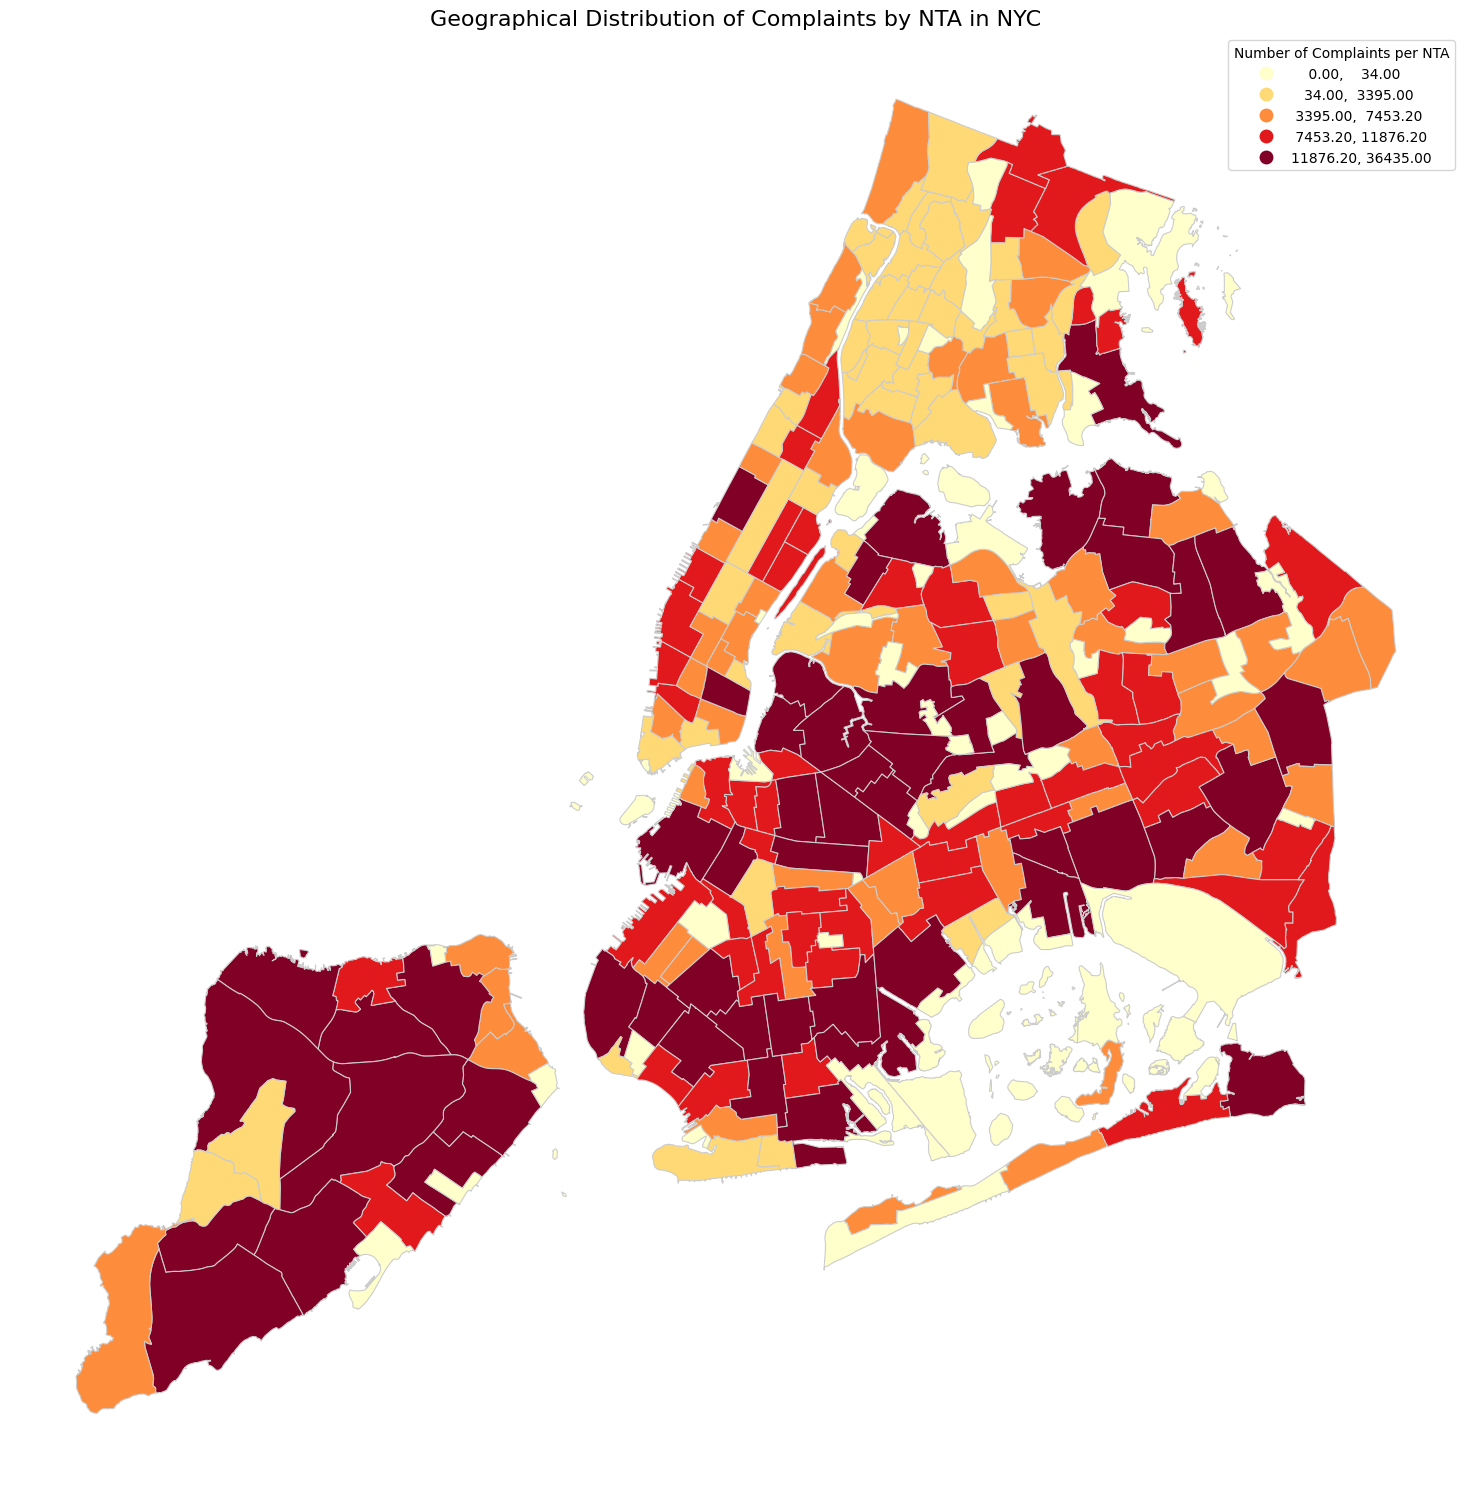

Choropleth map showing complaint distribution by NTA generated.


In [63]:
# Visualize Complaint Counts by NTA

# Merge the complaint counts with the nyc_nta_geo GeoDataFrame
# nyc_nta_geo contains the geometry for each NTA
nyc_nta_geo_merged = nyc_nta_geo.merge(complaints_per_nta, on='NTA2020', how='left')

# Fill NaN values in 'complaint_count' with 0 for NTAs with no complaints
nyc_nta_geo_merged['complaint_count'] = nyc_nta_geo_merged['complaint_count'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
n_bins = 5

nyc_nta_geo_merged.plot(
    column='complaint_count',
    cmap='YlOrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'title': "Number of Complaints per NTA"},
    scheme='Quantiles', # Using quantiles for better distribution across colors
    k=n_bins # Number of quantiles
)

ax.set_title('Geographical Distribution of Complaints by NTA in NYC', fontsize=16)
ax.set_axis_off() # Hide the axes
plt.tight_layout()
plt.show()

print("Choropleth map showing complaint distribution by NTA generated.")

In [64]:
complaints_with_nta.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1752860 entries, 180 to 1764550
Data columns (total 25 columns):
 #   Column          Dtype         
---  ------          -----         
 0   Created Date    object        
 1   Closed Date     object        
 2   Complaint Type  object        
 3   Location Type   object        
 4   Borough         object        
 5   Incident Zip    object        
 6   Latitude        float64       
 7   Longitude       float64       
 8   created_date    datetime64[ns]
 9   created_year    int32         
 10  created_month   int32         
 11  year_month      period[M]     
 12  geometry        geometry      
 13  index_right     int64         
 14  BoroCode        int32         
 15  BoroName        object        
 16  CountyFIPS      object        
 17  NTA2020         object        
 18  NTAName         object        
 19  NTAAbbrev       object        
 20  NTAType         object        
 21  CDTA2020        object        
 22  CDTAName     

In [65]:
# add year_month to complaints_with_nta
complaints_with_nta['Created Date'] = pd.to_datetime(complaints_with_nta['Created Date'])
complaints_with_nta['year_month'] = complaints_with_nta['Created Date'].dt.to_period('M')
complaints_with_nta['year_month'] = complaints_with_nta['year_month'].astype(str)

# Prepare files for leaflet

In [66]:
aggregated_records = complaints_with_nta.groupby(['year_month', 'NTA2020', 'Complaint Type']).size().reset_index(name='complaint_count')

num_aggregated_records = len(aggregated_records)

aggregated_records.to_csv('aggregated_records.csv', index=False)

In [67]:
# Aggregate aggregated_records by NTA2020 to get the total complaint count per NTA
nta_total_complaints = aggregated_records.groupby('NTA2020')['complaint_count'].sum().reset_index()

# Convert the aggregated DataFrame to JSON
output_json_path = 'nta_counts.json'
nta_total_complaints.to_json(output_json_path, orient='records', indent=4)

print(f"JSON file '{output_json_path}' created successfully with NTA2020 and total complaint counts.")
print("First 5 records of the JSON data:")
print(nta_total_complaints.head().to_json(orient='records', indent=4))

JSON file 'nta_counts.json' created successfully with NTA2020 and total complaint counts.
First 5 records of the JSON data:
[
    {
        "NTA2020":"BK0101",
        "complaint_count":17935
    },
    {
        "NTA2020":"BK0102",
        "complaint_count":17358
    },
    {
        "NTA2020":"BK0103",
        "complaint_count":7765
    },
    {
        "NTA2020":"BK0104",
        "complaint_count":14891
    },
    {
        "NTA2020":"BK0201",
        "complaint_count":5503
    }
]


In [68]:
# Define the output filename for the NTA boundaries GeoJSON
output_nta_geojson_path = 'nta_boundaries.geojson'

# Convert the nyc_nta_geo GeoDataFrame to GeoJSON format and save it
nyc_nta_geo.to_file(output_nta_geojson_path, driver='GeoJSON')

print(f"NTA boundary data successfully converted to GeoJSON and saved as '{output_nta_geojson_path}'")

NTA boundary data successfully converted to GeoJSON and saved as 'nta_boundaries.geojson'


# Join "NYC_census_tract.geojson" with df to create `census_tract_id` in df


Load the `NYC_census_tract.geojson` file into a GeoDataFrame to obtain the geographical boundaries of NYC census tracts.


In [15]:
import geopandas as gpd

# 1. Load the 'NYC_census_tract.geojson' file into a GeoDataFrame
nyc_census_tract_geo = gpd.read_file('/content/NYC_census_tract.geojson')

print("GeoDataFrame 'nyc_census_tract_geo' loaded successfully.")

# 2. Display the first few rows of the GeoDataFrame
print("\nFirst few rows of nyc_census_tract_geo:")
print(nyc_census_tract_geo.head())

# 3. Print the information about the GeoDataFrame
print("\nDataFrame info for nyc_census_tract_geo:")
nyc_census_tract_geo.info()

# 4. Print the Coordinate Reference System (CRS) of the GeoDataFrame
print(f"\nCRS of nyc_census_tract_geo: {nyc_census_tract_geo.crs}")

GeoDataFrame 'nyc_census_tract_geo' loaded successfully.

First few rows of nyc_census_tract_geo:
   OBJECTID CTLabel BoroCode   BoroName  CT2020 BoroCT2020 CDEligibil  \
0         1       1        1  Manhattan  000100    1000100          I   
1         2   14.01        1  Manhattan  001401    1001401          I   
2         3   14.02        1  Manhattan  001402    1001402          E   
3         4      18        1  Manhattan  001800    1001800          I   
4         5   22.01        1  Manhattan  002201    1002201          E   

                                             NTAName NTA2020 CDTA2020  \
0  The Battery-Governors Island-Ellis Island-Libe...  MN0191     MN01   
1                                    Lower East Side  MN0302     MN03   
2                                    Lower East Side  MN0302     MN03   
3                                    Lower East Side  MN0302     MN03   
4                                    Lower East Side  MN0302     MN03   

                        

The next step is to convert the `df` DataFrame into a GeoDataFrame using the 'Latitude' and 'Longitude' columns. This involves filtering out rows with missing geographical coordinates, creating shapely Point objects, and setting the appropriate CRS (EPSG:4326) to align with the `nyc_census_tract_geo` GeoDataFrame.



In [16]:
from shapely.geometry import Point

# Filter out rows with missing Latitude or Longitude
df_complaints_geo = df.dropna(subset=['Latitude', 'Longitude']).copy()

# Create point geometries
df_complaints_geo['geometry'] = df_complaints_geo.apply(
    lambda row: Point(row['Longitude'], row['Latitude']), axis=1
)

# Convert to GeoDataFrame and set CRS to EPSG:4326
geodata_complaints = gpd.GeoDataFrame(df_complaints_geo, geometry='geometry', crs='EPSG:4326')

print("GeoDataFrame 'geodata_complaints' created successfully from 'df'.")
print("First few rows of geodata_complaints:")
print(geodata_complaints.head())
print(f"\nShape of geodata_complaints: {geodata_complaints.shape}")
print(f"\nCRS of geodata_complaints: {geodata_complaints.crs}")

GeoDataFrame 'geodata_complaints' created successfully from 'df'.
First few rows of geodata_complaints:
     Unique Key             Created Date              Closed Date  \
180    27025605  2013 Dec 31 12:27:00 PM  2014 Jan 09 12:00:00 PM   
181    27028413  2013 Dec 31 11:13:00 AM  2014 Jan 02 12:00:00 PM   
182    27027316  2013 Dec 31 10:27:00 AM  2014 Jan 05 12:00:00 PM   
183    27026170  2013 Dec 31 10:05:00 AM  2014 Jan 02 12:00:00 PM   
184    27016863  2013 Dec 30 02:19:00 PM  2013 Dec 31 12:00:00 PM   

                 Complaint Type Location Type   Borough  Incident Zip  \
180  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN       11214.0   
181  Sweeping/Missed-Inadequate      Sidewalk     BRONX       10472.0   
182  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN       11215.0   
183  Sweeping/Missed-Inadequate      Sidewalk     BRONX       10472.0   
184  Sweeping/Missed-Inadequate      Sidewalk    QUEENS       11369.0   

      Latitude  Longitude        created_d

The next step is to spatially join the `geodata_complaints` with `nyc_census_tract_geo` to assign a census tract ID to each complaint. Then, the extracted census tract IDs will be merged back into the main `df` DataFrame based on the 'Unique Key' to fulfill the task's requirement.



In [17]:
import geopandas as gpd

# Ensure both GeoDataFrames have the same CRS before spatial joining
# geodata_complaints and nyc_census_tract_geo already have EPSG:4326

# Perform spatial join using 'within' predicate
# Use a left join to keep all complaints from geodata_complaints
complaints_with_census_tract = gpd.sjoin(
    geodata_complaints,
    nyc_census_tract_geo[['GEOID', 'geometry']], # Select only necessary columns from census tracts
    how='left',
    predicate='within'
)

print("Spatial join completed successfully.")
print("First few rows of complaints_with_census_tract (joined with census tract data):")
print(complaints_with_census_tract.head())
print(f"\nShape of complaints_with_census_tract: {complaints_with_census_tract.shape}")

# Prepare the census tract ID for merging back to the original df
census_tract_mapping = complaints_with_census_tract[['Unique Key', 'GEOID']].copy()
census_tract_mapping.rename(columns={'GEOID': 'census_tract_id'}, inplace=True)

# Merge the census_tract_id back into the original df DataFrame
df = df.merge(census_tract_mapping, on='Unique Key', how='left')

print("\nCensus tract IDs merged back into the original 'df' DataFrame.")
print("First few rows of 'df' with the new 'census_tract_id' column:")
print(df[['Unique Key', 'Latitude', 'Longitude', 'census_tract_id']].head())
print(f"\nColumns in 'df' after merge: {df.columns.tolist()}")

Spatial join completed successfully.
First few rows of complaints_with_census_tract (joined with census tract data):
     Unique Key             Created Date              Closed Date  \
180    27025605  2013 Dec 31 12:27:00 PM  2014 Jan 09 12:00:00 PM   
181    27028413  2013 Dec 31 11:13:00 AM  2014 Jan 02 12:00:00 PM   
182    27027316  2013 Dec 31 10:27:00 AM  2014 Jan 05 12:00:00 PM   
183    27026170  2013 Dec 31 10:05:00 AM  2014 Jan 02 12:00:00 PM   
184    27016863  2013 Dec 30 02:19:00 PM  2013 Dec 31 12:00:00 PM   

                 Complaint Type Location Type   Borough  Incident Zip  \
180  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN       11214.0   
181  Sweeping/Missed-Inadequate      Sidewalk     BRONX       10472.0   
182  Sweeping/Missed-Inadequate      Sidewalk  BROOKLYN       11215.0   
183  Sweeping/Missed-Inadequate      Sidewalk     BRONX       10472.0   
184  Sweeping/Missed-Inadequate      Sidewalk    QUEENS       11369.0   

      Latitude  Longitude    

In [35]:
# save df to csv
df = df[['Unique Key', 'Created Date', 'Complaint Type', 'Borough', 'Incident Zip', 'Latitude', 'Longitude', 'created_date', 'year_month', 'census_tract_id']]

df.to_csv('nyc_complaints_census_tract.csv', index=False)

## Aggregate on year_month, complaint_type, and census_tract_id

In [37]:
# Aggregate on year_month, complaint_type, and census_tract_id
df_temp = df.copy()
df_temp['year_month'] = df_temp['year_month'].astype(str)
aggregated_df = df_temp.groupby(['year_month', 'Complaint Type', 'census_tract_id']).size().reset_index(name='complaint_count')
df_temp = None

In [40]:
aggregated_df.to_csv('aggregated_complaint_census_tract.csv', index=False)

In [41]:
aggregated_df.to_json('aggregated_complaint_census_tract.json', orient='records', indent=4)
print("DataFrame saved to 'aggregated_complaint_census_tract.json'")

DataFrame saved to 'aggregated_complaint_census_tract.json'
